<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/Convolutional_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Convolutional Neural Networks:

In typical neural networks, every neuron process data from over single input from previous layer and adjust itself.

But some tasks require us to find patterns and some specific stuffs. So, instead of asking every single neuron to find every single patterns, we can specific use neurons to find specific patterns. Convolutional Neural Network does exact that. Instead of all the neurons looking and the whole day, neurons are fed specific data at once and asked to find pattern. Then it's fed another set of data.


Each neuron works like a filter (inside, they have a matrix). We specify the number of neurons inside and then each neurons work like filter. Each neuron go over the input and looks for pattern from the input. (It's actually matrix multiplication).

Let's use an example:

```
model = tf.keras.Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
]
```

Here's we are creating 32 filters, all are 3X3 filters[Matrix]. The inputs are 28X28 matrix.

32 filters go over the image, and then they look for 32 different patterns. Each time, they are fed only 3X3 = 9 pixels to find the pattern and, it goes over all the img.

One layer pass their outputs as inputs to the next layer and the next layer uses different filters to scan the outputs and find pattern from there.

For example:
edge + edge → corner → corner + curve → eye → eye + nose → face
This is how it decides it's a cat or dog or elephant.

Now, the back propagation:
Wrong prediction → Compute gradients → Adjust filter → Slightly better → Repeat millions of times

one filter becomes : Vertical edge detector

another becomes : Circle detector

Nobody tells it. It learns.

## Import Lib & Load Dataset

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(x_train.shape)
print(y_train.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)


## Visualize one img

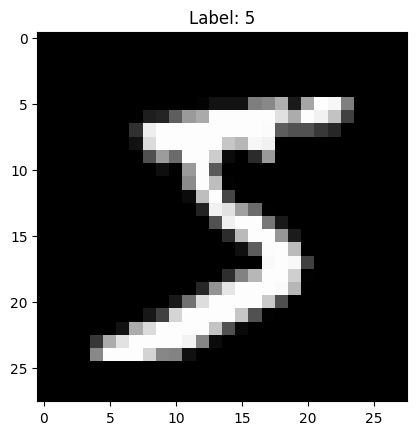

In [3]:
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

## Normalize imag

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## Add Channel Dimension

CNN expects:
(height, width, channels)

Current shape:
(60000, 28, 28)

Need:
(60000, 28, 28, 1)

In [5]:
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(x_train.shape)

(60000, 28, 28, 1)


## Build CNN

In [6]:
model=models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


> Notice that we increase the number of filters in the early convolutional layers. The first convolutional layer usually learns simple features such as edges and corners. The deeper convolutional layers combine these simple features to learn more complex features, such as eyes, ears, wheels, or faces. Therefore, it is common to increase the number of filters as the network goes deeper.

> After the convolutional layers extract features, we flatten the feature maps into a 1D vector. Then, one or more Dense layers perform classification by combining the extracted features. Finally, the output Dense layer (with softmax) produces a probability for each class. We use argmax() to select the class with the highest probability.

```
Image
→ Convolution Layers (increasing filters, extracting increasingly complex features)
→ Flatten
→ Dense Layers (classification)
→ Softmax Output (Shows the probability)
→ argmax (final prediction)
```

> Conv2D -> for convolutional layer for 2D matrix, the matrix slides in 2D plane, both up-down and right-left.

> Conv2D applies multiple learnable filters (kernels) that slide over the image (or feature maps) to detect useful patterns such as edges, corners, and textures.

> MaxPooling slides a small window (usually 2×2) over each feature map and keeps only the maximum value from each window.

The next convolution layer doesn't see the original image anymore.

It sees the **feature maps** created by the previous layer.

> So instead of detecting simple edges, it can learn combinations of those edges to recognize more complex shapes.

> **Conv2D applies multiple learnable filters (kernels) that slide over the image (or feature maps) to detect useful patterns such as edges, corners, and textures.**



## See Architecture

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compile

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train

In [10]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    verbose=False,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.9473 - loss: 0.1693 - val_accuracy: 0.9789 - val_loss: 0.0710
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 77s 25ms/step - accuracy: 0.9839 - loss: 0.0534 - val_accuracy: 0.9870 - val_loss: 0.0426
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9890 - loss: 0.0358 - val_accuracy: 0.9892 - val_loss: 0.0380
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9914 - loss: 0.0266 - val_accuracy: 0.9872 - val_loss: 0.0447
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9931 - loss: 0.0202 - val_accuracy: 0.9872 - val_loss: 0.0466


## Evaluate

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9891 - loss: 0.0376
Test Accuracy: 0.9890999794006348


## Predict

In [12]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


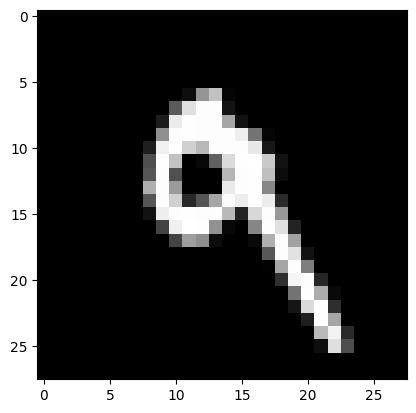

Actual: 9
Wihtout argmax : [4.0189806e-11 3.8178786e-07 1.3569787e-05 9.6512274e-05 2.4820762e-04
 7.8883377e-06 2.5595151e-12 3.3206937e-10 3.1385556e-05 9.9960214e-01]
Predicted: 9


In [15]:
import numpy as np

index = 7

plt.imshow(x_test[index].squeeze(), cmap="gray")
plt.show()

print("Actual:", y_test[index])
print(f"Wihtout argmax : {predictions[index]}")
print("Predicted:", np.argmax(predictions[index]))

## Plot Accuracy

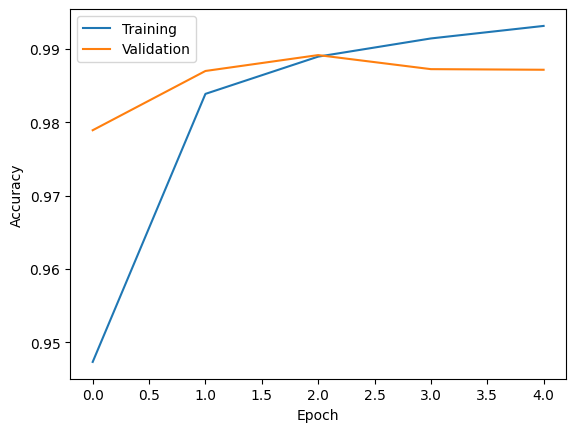

In [14]:
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


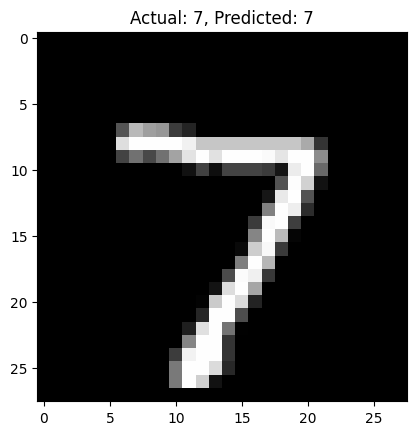

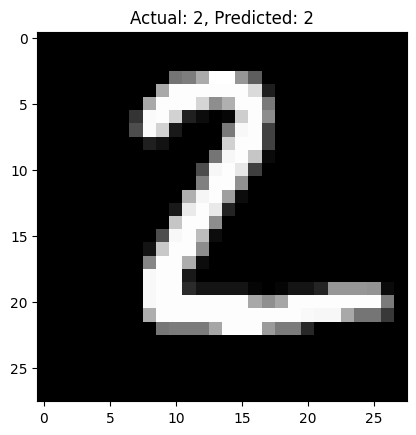

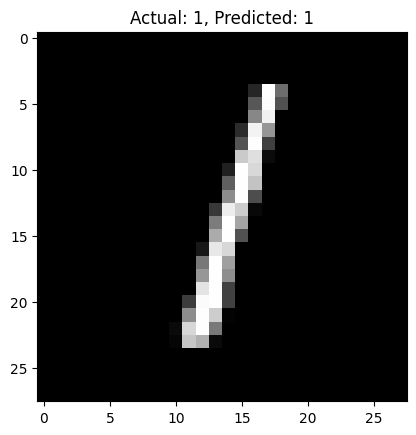

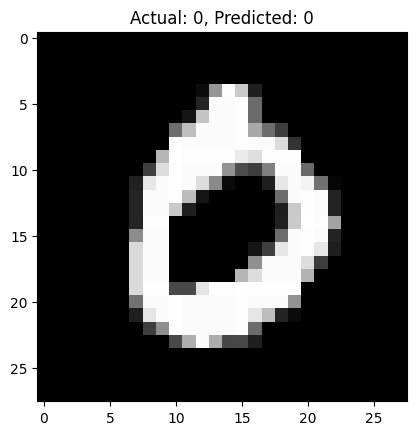

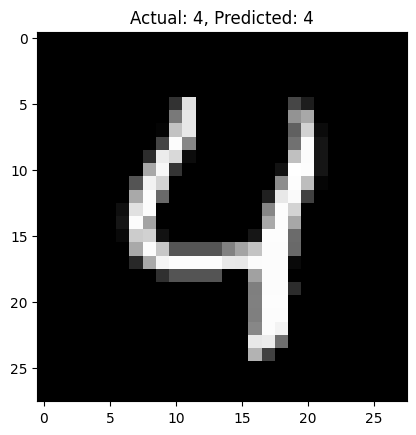

In [16]:
import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(x_test)

for i in range(5):
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(
        f"Actual: {y_test[i]}, Predicted: {np.argmax(predictions[i])}"
    )
    plt.show()